In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

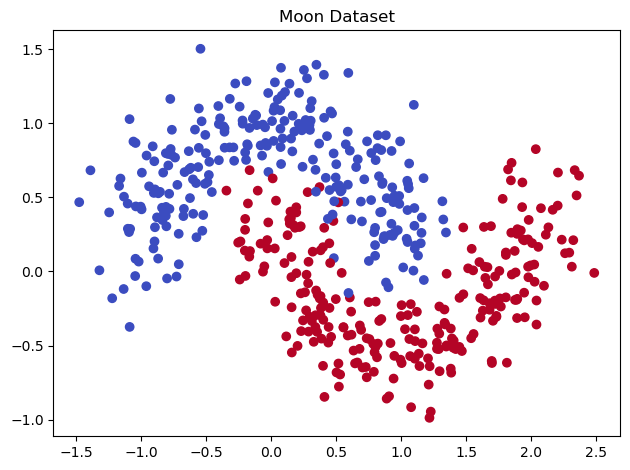

In [3]:
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")
plt.title("Moon Dataset")
plt.tight_layout()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
accuracy_score(y_test, y_pred_log)

0.86

In [7]:
svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train, y_train)
y_pred_svm_linear = svm_linear.predict(X_test)
accuracy_score(y_test, y_pred_svm_linear)

0.86

In [8]:
svm_rbf = SVC(kernel="rbf", C=1, gamma=0.1)
svm_rbf.fit(X_train, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test)
print(accuracy_score(y_test, y_pred_svm_rbf))
print(confusion_matrix(y_test, y_pred_svm_rbf))
print(classification_report(y_test, y_pred_svm_rbf))

0.87
[[41  2]
 [11 46]]
              precision    recall  f1-score   support

           0       0.79      0.95      0.86        43
           1       0.96      0.81      0.88        57

    accuracy                           0.87       100
   macro avg       0.87      0.88      0.87       100
weighted avg       0.89      0.87      0.87       100



In [9]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10],
    'kernel' : ['rbf']
}
grid = GridSearchCV(SVC(), param_grid, cv=5, verbose=2)
grid.fit(X_train, y_train)
grid.best_params_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1

{'C': 0.1, 'gamma': 10, 'kernel': 'rbf'}

In [10]:
# Training model after hyperparameter tuning
best_model = grid.best_estimator_
y_pred_svm_rbf_tuned = best_model.predict(X_test)
accuracy_score(y_test, y_pred_svm_rbf_tuned)

0.97

In [11]:
def plot_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title(title)
    plt.tight_layout()

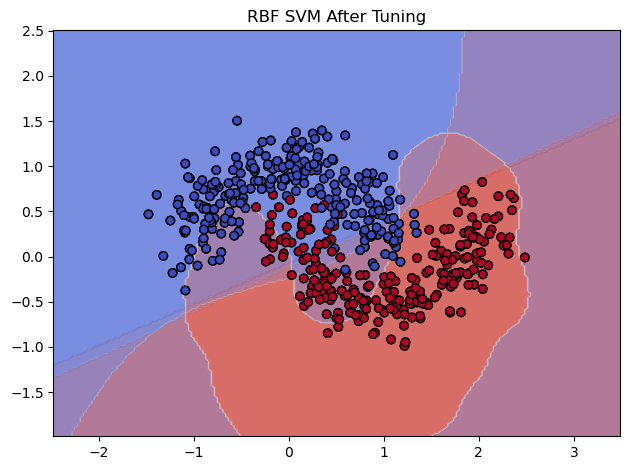

In [12]:
plot_boundary(log_model, X, y, "Logistic Regression")
plot_boundary(svm_linear, X, y, "Linear SVM")
plot_boundary(svm_rbf, X, y, "RBF SVM")
plot_boundary(best_model, X, y, "RBF SVM After Tuning")

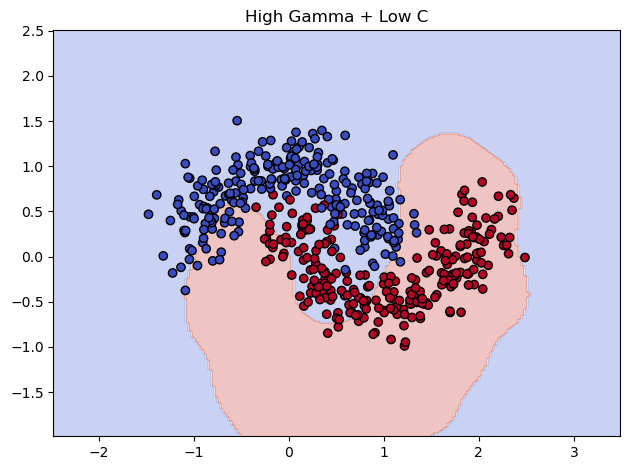

In [13]:
svm_test = SVC(kernel='rbf', C=0.1, gamma=10)
svm_test.fit(X_train, y_train)
plot_boundary(svm_test, X, y, "High Gamma + Low C")

# Conclusion:
The moon dataset is inherently non-linear, where linear models like Logistic Regression and Linear SVM fail to capture the curved decision boundary. RBF SVM performs significantly better by handling non-linearity, but its performance is highly dependent on hyperparameters. After tuning, the model achieved a strong balance between flexibility and generalization (high gamma for capturing complex patterns and low C to avoid overfitting noise), resulting in improved accuracy. This experiment highlights that model performance depends not just on the algorithm, but on proper hyperparameter tuning and understanding the data structure.